In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.cluster import HDBSCAN 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import NearestNeighbors

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None) # Mostrar todas as colunas

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# Recarregando os dados para garantir a integridade
data_path = '../../data/raw/UNSW-NB15'

df_train = pd.read_csv(os.path.join(data_path, 'UNSW_NB15_training-set.csv'))
df_test = pd.read_csv(os.path.join(data_path, 'UNSW_NB15_testing-set.csv'))

df_train = df_train.drop('id', axis=1)
df_test = df_test.drop('id', axis=1)
df_train['service'] = df_train['service'].replace('-', 'unknown')
df_test['service'] = df_test['service'].replace('-', 'unknown')

print("\nDados carregados.")

# Filtrar o conjunto de treino para conter APENAS o tráfego normal
df_train_normal = df_train[df_train['label'] == 0]
X_train_normal = df_train_normal.drop(['attack_cat', 'label'], axis=1)

# Preparar o conjunto de teste completo para a aplicação do DBSCAN
X_test = df_test.drop(['attack_cat', 'label'], axis=1)
y_test = df_test['label'] # Rótulos verdadeiros para avaliação final

# Definir o pré-processador
numeric_features = X_train_normal.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train_normal.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Ajustar (fit) o pré-processador nos dados de treino normais
print("Ajustando o pré-processador nos dados normais...")
preprocessor.fit(X_train_normal)

# Transformar o conjunto de teste
print("Transformando o conjunto de teste...")
X_test_processed = preprocessor.transform(X_test)

print("Dados de teste pré-processados e prontos.")


Dados carregados.
Ajustando o pré-processador nos dados normais...
Transformando o conjunto de teste...
Dados de teste pré-processados e prontos.


Criando uma subamostra de 25% dos dados de teste...
Tamanho da amostra para análise: 20583 pontos.

Executando o sklearn.cluster.HDBSCAN na amostra...

Número de clusters encontrados: 132
Número de pontos de ruído (anomalias): 6885

--- Relatório de Classificação Binária (HDBSCAN na Amostra) ---
              precision    recall  f1-score   support

  Normal (0)       0.54      0.80      0.65      9250
  Ataque (1)       0.74      0.45      0.56     11333

    accuracy                           0.61     20583
   macro avg       0.64      0.63      0.60     20583
weighted avg       0.65      0.61      0.60     20583



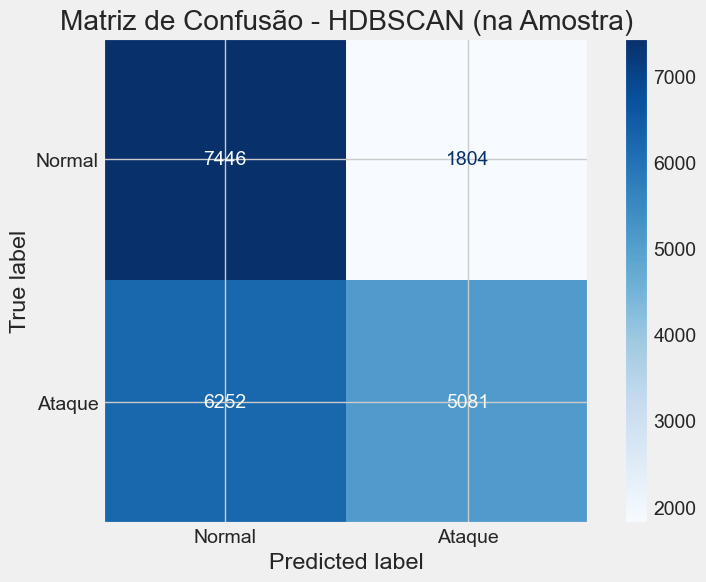

In [3]:
# --- Subamostragem do Conjunto de Teste ---
sample_fraction = 0.25
print(f"Criando uma subamostra de {sample_fraction*100:.0f}% dos dados de teste...")

# Criar um DataFrame temporário para facilitar a amostragem estratificada
df_test_processed = pd.DataFrame(X_test_processed)
df_test_processed['label'] = y_test.values
df_test_sample, _ = train_test_split(df_test_processed, train_size=sample_fraction, stratify=df_test_processed['label'], random_state=42)

# Separar X e y da amostra
X_test_sample = df_test_sample.drop('label', axis=1).values
y_test_sample = df_test_sample['label'].values
# X_test_sample = df_test_processed.drop('label', axis=1).values
# y_test_sample = df_test_processed['label'].values
print(f"Tamanho da amostra para análise: {len(X_test_sample)} pontos.")

# --- Execução do HDBSCAN do Scikit-learn ---
# Os parâmetros são os mesmos da biblioteca externa
hdbscan_clusterer = HDBSCAN(
    min_cluster_size=15,
    min_samples=15,
    metric='euclidean'
)

print(f"\nExecutando o sklearn.cluster.HDBSCAN na amostra...")
y_pred_hdbscan = hdbscan_clusterer.fit_predict(X_test_sample)

# Analisar os resultados da clusterização
n_clusters = len(set(y_pred_hdbscan)) - (1 if -1 in y_pred_hdbscan else 0)
n_noise = np.sum(y_pred_hdbscan == -1)
print(f"\nNúmero de clusters encontrados: {n_clusters}")
print(f"Número de pontos de ruído (anomalias): {n_noise}")

# Mapear os resultados para avaliação (0: Normal, 1: Ataque)
y_pred_mapped = np.where(y_pred_hdbscan == -1, 1, 0)

# Avaliar os resultados usando os rótulos verdadeiros da amostra (y_test_sample)
print("\n--- Relatório de Classificação Binária (HDBSCAN na Amostra) ---")
print(classification_report(y_test_sample, y_pred_mapped, target_names=['Normal (0)', 'Ataque (1)']))

cm = confusion_matrix(y_test_sample, y_pred_mapped)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Ataque'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusão - HDBSCAN (na Amostra)')
plt.savefig('confusion_matrix_multi_hdbscan.png')
plt.show()

In [4]:
try:
    # Salvar o Pré-processador
    # Este é o único objeto "treinado" reutilizável deste script
    joblib.dump(preprocessor, 'preprocessor_HDBSCAN.joblib')
    joblib.dump(hdbscan_clusterer, 'model_HDBSCAN.joblib')
    print("Objeto 'preprocessor' salvo com sucesso.")

except Exception as e:
    print(f"Ocorreu um erro ao salvar os arquivos: {e}")

Objeto 'preprocessor' salvo com sucesso.
